In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torchvision import transforms
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import traceback
import time

In [13]:
# Add CUDA debugging environment variable (makes CUDA calls synchronous, helps pinpoint errors)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Clear cache if GPU is available
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using device: cuda


In [14]:
!nvidia-smi

Thu Apr 17 21:32:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.60                 Driver Version: 572.60         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P0             18W /   95W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
def set_seed(seed=42):
     """Sets random seeds for reproducibility."""
     random.seed(seed)
     np.random.seed(seed)
     torch.manual_seed(seed)

     # Set CUDA seeds if available
     if torch.cuda.is_available():
         try:
             torch.cuda.manual_seed(seed)
             torch.cuda.manual_seed_all(seed) # for multi-GPU
             # Ensure deterministic behavior (can slow down training)
             torch.backends.cudnn.deterministic = True
             torch.backends.cudnn.benchmark = False
         except RuntimeError as e:
             print(f"Warning: CUDA seed setting failed: {e}. Continuing without CUDA-specific seed.")

In [16]:
# Configuration Class
class Config:
     """Stores configuration parameters for the experiment."""
     # Dataset parameters
     dataset_name = "timm/mini-imagenet"
     img_size = 84  # Mini-ImageNet images are 84x84
     n_channels = 3

     # Few-shot learning setup
     n_ways = 5      # Number of classes in each task (must match ViT output)
     n_shots = 5     # Number of support examples per class
     n_query = 15    # Number of query examples per class for validation/testing within task

     # Diffusion model parameters
     diffusion_n_steps = 500      # Fewer steps for faster training/sampling (Consider increasing if quality is poor)
     beta_start = 1e-4
     beta_end = 0.02
     model_hidden_dim = 64       # Reduced U-Net hidden dim for memory
     model_channels = 32         # Reduced U-Net channels for memory
     model_attn_resolutions = [16] # Resolutions where attention is applied
     diffusion_dropout = 0.1
     diffusion_epochs = 150      # Increased epochs slightly (Adjust based on resources)
     diffusion_batch_size = 8    # Reduced batch size for memory
     diffusion_lr = 1e-4
     n_synthetic_per_class = 30  # Number of synthetic images to generate per class

     # ViT parameters
     vit_patch_size = 4          # Patch size for ViT
     vit_dim = 128               # Reduced embedding dimension for memory
     vit_depth = 4               # Reduced number of transformer blocks
     vit_heads = 4               # Reduced number of attention heads
     vit_mlp_dim = 512           # Reduced MLP dimension in ViT blocks
     vit_dropout = 0.1

     # Training parameters
     vit_epochs = 100             # Reduced epochs for faster runs
     vit_batch_size = 8          # Reduced batch size for memory
     vit_lr = 1e-4               # Initial LR for baseline training
     vit_finetune_lr = 5e-5      # Lower LR for fine-tuning with augmented data
     weight_decay = 1e-4
     num_classes = 5             # Default number of classes for ViT (should match n_ways)
     early_stopping_patience = 15 # Number of epochs to wait for improvement before stopping

In [17]:
# Global cache for datasets to avoid reloading
cached_data = {
    'train_dataset': None,
    'val_dataset': None,
    'test_dataset': None,
    'n_classes': None,      # Total classes in original dataset
    'class_to_idx': None    # Mapping for original dataset
}

In [26]:
#-------------------------------------------------------------------
# 1. Data Loading and Preprocessing (Keep original code)
#-------------------------------------------------------------------
class MiniImageNetDataset(Dataset):
     """Custom Dataset wrapper for HuggingFace Mini-ImageNet."""
     def __init__(self, dataset_split, transform=None):
         self.dataset = dataset_split
         self.transform = transform

     def __len__(self):
         return len(self.dataset)

     def __getitem__(self, idx):
         # Access data using dictionary keys
         item = self.dataset[idx]
         img = item['image']
         label = item['label']

         # Ensure image is PIL and in RGB format
         if not isinstance(img, Image.Image):
             # Assuming it might be numpy array or tensor, convert to PIL
             if isinstance(img, np.ndarray):
                 img = Image.fromarray(img)
             elif isinstance(img, torch.Tensor):
                 # Handle tensor conversion (assuming CHW or HWC)
                 if img.dim() == 3 and img.shape[0] == 3: # CHW
                     img = transforms.ToPILImage()(img)
                 elif img.dim() == 3 and img.shape[2] == 3: # HWC
                     img = Image.fromarray(img.numpy().astype(np.uint8))
                 elif img.dim() == 2: # Grayscale? Convert to RGB
                     img = Image.fromarray(img.numpy().astype(np.uint8)).convert('RGB')
                 else:
                     # Fallback or raise error for unexpected tensor shapes
                     print(f"Warning: Unexpected tensor shape {img.shape} at index {idx}. Trying to convert.")
                     try:
                         img = transforms.ToPILImage()(img) # Attempt conversion
                     except Exception as e:
                         print(f"Error converting tensor to PIL: {e}. Returning placeholder.")
                         # Return a placeholder or raise error
                         return torch.zeros(Config.n_channels, Config.img_size, Config.img_size), -1 # Placeholder

         # Convert non-RGB PIL images to RGB
         if img.mode != 'RGB':
             img = img.convert('RGB')

         # Apply transformations if provided
         if self.transform:
             img = self.transform(img)

         # Return image tensor and integer label
         return img, int(label)

class SafeSubset(Subset):
     """
     A custom Subset class that ensures labels are properly converted to correct dtype.
     Needed if the underlying dataset returns labels in a non-standard format.
     """
     def __getitem__(self, idx):
         # Get data from the original dataset using the mapped index
         data, label = self.dataset[self.indices[idx]]
         # Ensure label is a standard Python integer
         return data, int(label)

def load_mini_imagenet():
     """Loads the Mini-ImageNet dataset using HuggingFace datasets, with caching."""
     # Check cache first
     if cached_data['train_dataset'] is not None:
         print("Using cached datasets...")
         return (cached_data['train_dataset'],
                 cached_data['val_dataset'],
                 cached_data['test_dataset'],
                 cached_data['n_classes'],
                 cached_data['class_to_idx'])

     print("Loading and preprocessing Mini-ImageNet data...")
     try:
         # Load the dataset from HuggingFace Hub
         dataset = load_dataset(Config.dataset_name, trust_remote_code=True) # Added trust_remote_code=True if needed
     except Exception as e:
         print(f"Error loading dataset '{Config.dataset_name}': {e}")
         print("Please ensure the dataset name is correct and you have internet access.")
         raise

     # Define image transformations
     # Train transform includes augmentation
     train_transform = transforms.Compose([
         transforms.Resize((Config.img_size, Config.img_size)),
         transforms.RandomHorizontalFlip(),
         transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
         transforms.ToTensor(), # Converts PIL Image (H x W x C) [0, 255] to FloatTensor (C x H x W) [0.0, 1.0]
         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
     ])

     # Test transform only resizes, converts to tensor, and normalizes
     test_transform = transforms.Compose([
         transforms.Resize((Config.img_size, Config.img_size)),
         transforms.ToTensor(),
         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
     ])

     # Create Dataset instances for each split
     train_dataset = MiniImageNetDataset(dataset['train'], transform=train_transform)
     val_dataset = MiniImageNetDataset(dataset['validation'], transform=test_transform)
     test_dataset = MiniImageNetDataset(dataset['test'], transform=test_transform)

     # Extract class information from the training set
     try:
         all_labels = [item['label'] for item in dataset['train']]
         all_classes = sorted(list(set(all_labels)))
         n_classes = len(all_classes)
         class_to_idx = {cls_name: idx for idx, cls_name in enumerate(all_classes)}
         print(f"Found {n_classes} unique classes in the original training set.")
     except Exception as e:
         print(f"Error extracting class information: {e}")
         # Fallback if label structure is different
         n_classes = -1
         class_to_idx = {}


     # Cache the loaded data
     cached_data['train_dataset'] = train_dataset
     cached_data['val_dataset'] = val_dataset
     cached_data['test_dataset'] = test_dataset
     cached_data['n_classes'] = n_classes
     cached_data['class_to_idx'] = class_to_idx

     print("Dataset loading complete.")
     return train_dataset, val_dataset, test_dataset, n_classes, class_to_idx

class FewShotSubset(Dataset):
     """
     A custom dataset subset specifically for few-shot tasks.
     It takes a list of (original_index, new_label, original_label) tuples
     and returns the data corresponding to original_index but with new_label.
     """
     def __init__(self, original_dataset, indices_and_labels):
         self.original_dataset = original_dataset
         # Store list of tuples: (original_dataset_index, remapped_few_shot_label, original_label)
         self.indices_and_labels = indices_and_labels
         print(f"FewShotSubset created with {len(indices_and_labels)} samples.")
         # Optional: Validate indices are within bounds of original_dataset
         max_original_idx = max(idx for idx, _, _ in indices_and_labels) if indices_and_labels else -1
         if indices_and_labels and max_original_idx >= len(original_dataset):
              raise ValueError(f"Index out of bounds in FewShotSubset: Max index {max_original_idx} >= Dataset length {len(original_dataset)}")


     def __getitem__(self, idx):
         # Get the mapping information for the requested index
         original_idx, new_label, _ = self.indices_and_labels[idx]
         # Retrieve the data (image) from the original dataset using the original index
         data, _ = self.original_dataset[original_idx] # We ignore the original label here
         # Return the data paired with the *new* remapped label
         return data, int(new_label) # Ensure label is int

     def __len__(self):
         # The length of the subset is the number of mappings provided
         return len(self.indices_and_labels)

In [27]:
#-------------------------------------------------------------------
# 2. Few-Shot Learning Setup (Keep original code)
#-------------------------------------------------------------------

class FewShotDataset:
     """Handles the creation of few-shot classification tasks (support and query sets)."""
     def __init__(self, dataset, n_ways, n_shots, n_query):
         self.dataset = dataset
         self.n_ways = n_ways
         self.n_shots = n_shots
         self.n_query = n_query

         # Organize dataset indices by their original class label
         self.samples_by_class = {}
         print("Organizing samples by class...")
         for idx in tqdm(range(len(dataset))):
             try:
                 _, label = dataset[idx] # Get label for each item
                 label = int(label) # Ensure label is int
                 if label not in self.samples_by_class:
                     self.samples_by_class[label] = []
                 self.samples_by_class[label].append(idx)
             except Exception as e:
                 print(f"Warning: Could not process item at index {idx}. Error: {e}. Skipping.")
                 continue # Skip problematic items

         self.classes = sorted(list(self.samples_by_class.keys()))
         print(f"Found {len(self.classes)} classes with samples.")

         # Check if we have enough samples per class for the task setup
         for label, indices in self.samples_by_class.items():
             if len(indices) < (n_shots + n_query):
                 print(f"Warning: Class {label} only has {len(indices)} samples, "
                       f"less than required n_shots({n_shots}) + n_query({n_query}) = {n_shots + n_query}.")


     def create_few_shot_task(self):
         """Creates a single N-way, K-shot task with support and query sets."""
         support_samples = [] # List of (original_index, new_label, original_label)
         query_samples = []   # List of (original_index, new_label, original_label)

         # Select N classes randomly from available classes
         valid_classes = [cls for cls, indices in self.samples_by_class.items() if len(indices) >= (self.n_shots + self.n_query)]
         if len(valid_classes) < self.n_ways:
              raise ValueError(f"Not enough classes ({len(valid_classes)}) with sufficient samples ({self.n_shots + self.n_query}) "
                               f"to create a {self.n_ways}-way task.")

         selected_classes = random.sample(valid_classes, self.n_ways)

         # For each selected class, sample K support and Q query examples
         for class_idx, original_label in enumerate(selected_classes):
             # Get all sample indices for this original class
             class_sample_indices = self.samples_by_class[original_label]

             # Randomly select K+Q samples without replacement
             selected_indices = random.sample(class_sample_indices, self.n_shots + self.n_query)

             # Assign the *new* sequential label (0 to N-1)
             new_label = class_idx

             # Add K samples to support set
             support_samples.extend([(idx, new_label, original_label) for idx in selected_indices[:self.n_shots]])
             # Add Q samples to query set
             query_samples.extend([(idx, new_label, original_label) for idx in selected_indices[self.n_shots:]])

         # Return the lists of mappings and the original classes selected for this task
         return support_samples, query_samples, selected_classes

     def create_fixed_few_shot_dataset(self, num_tasks=1):
         """Creates a fixed set of few-shot tasks for consistent experiments."""
         all_support_sets = []
         all_query_sets = []
         all_original_classes = []

         print(f"Creating {num_tasks} few-shot task(s)...")
         for i in range(num_tasks):
             try:
                 support, query, selected_classes = self.create_few_shot_task()
                 all_support_sets.append(support)
                 all_query_sets.append(query)
                 all_original_classes.append(selected_classes)
                 print(f"  Task {i+1}: Created with classes {selected_classes}")
             except ValueError as e:
                 print(f"Error creating task {i+1}: {e}")
                 # Decide whether to stop or continue
                 raise # Stop if any task fails

         return all_support_sets, all_query_sets, all_original_classes

def create_few_shot_loaders(original_dataset, support_indices_and_labels, query_indices_and_labels, batch_size):
    """
    Creates DataLoaders for the support and query sets using FewShotSubset.
    Args:
        original_dataset: The full dataset (e.g., train_dataset).
        support_indices_and_labels: List of (orig_idx, new_label, orig_label) for support set.
        query_indices_and_labels: List of (orig_idx, new_label, orig_label) for query set.
        batch_size: Batch size for the DataLoaders.
    Returns:
        support_loader, query_loader, support_labels (new), query_labels (new),
        support_orig_labels, query_orig_labels
    """
    print("Creating DataLoaders for few-shot task...")
    # Create FewShotSubset instances which handle the label remapping
    support_set = FewShotSubset(original_dataset, support_indices_and_labels)
    query_set = FewShotSubset(original_dataset, query_indices_and_labels)

    # Create DataLoaders
    # *** FIX: Set num_workers=0 ***
    support_loader = DataLoader(support_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False) # Set num_workers=0, pin_memory=False if num_workers=0
    query_loader = DataLoader(query_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False) # Set num_workers=0, pin_memory=False if num_workers=0

    # Extract labels for reference (optional, but useful for checks)
    support_new_labels = [int(new_label) for _, new_label, _ in support_indices_and_labels]
    query_new_labels = [int(new_label) for _, new_label, _ in query_indices_and_labels]
    support_orig_labels = [orig_label for _, _, orig_label in support_indices_and_labels]
    query_orig_labels = [orig_label for _, _, orig_label in query_indices_and_labels]

    print(f"Support loader: {len(support_set)} samples, Query loader: {len(query_set)} samples.")
    # Sanity check labels
    if support_new_labels:
        print(f"  Support set new labels range: [{min(support_new_labels)}, {max(support_new_labels)}]")
    if query_new_labels:
        print(f"  Query set new labels range: [{min(query_new_labels)}, {max(query_new_labels)}]")

    return support_loader, query_loader, support_new_labels, query_new_labels, support_orig_labels, query_orig_labels

In [28]:
#-------------------------------------------------------------------
# 3. Diffusion Model Implementation (Keep original code, but ensure U-Net structure is sound)
#-------------------------------------------------------------------

def get_timestep_embedding(timesteps, embedding_dim):
     """
     Creates sinusoidal positional embeddings for timesteps.
     From Fairseq implementation.
     Args:
         timesteps: 1-D Tensor of N indices (batch size).
         embedding_dim: The dimension of the embedding vector.
     Returns:
         [N x embedding_dim] Tensor of positional embeddings.
     """
     assert len(timesteps.shape) == 1, "Timesteps should be a 1D tensor"

     half_dim = embedding_dim // 2
     # Scale factor for frequency calculation
     emb = np.log(10000) / (half_dim - 1)
     # Create frequency values
     emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * -emb)
     # Calculate embeddings: timesteps * frequencies
     emb = timesteps.float()[:, None] * emb[None, :]
     # Concatenate sin and cos components
     emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

     # Handle odd embedding dimensions by padding with zeros
     if embedding_dim % 2 == 1:
         emb = F.pad(emb, (0, 1)) # Pad last dimension

     assert emb.shape == (timesteps.shape[0], embedding_dim), "Output embedding shape mismatch"
     return emb

class ResidualBlock(nn.Module):
     """Residual block with GroupNorm, SiLU, Conv, Dropout."""
     def __init__(self, in_channels, out_channels, dropout=0.1, time_emb_dim=None):
         super().__init__()
         self.in_channels = in_channels
         self.out_channels = out_channels

         # First part of the block
         self.norm1 = nn.GroupNorm(min(32, in_channels), in_channels) # Ensure group size <= num_channels
         self.act1 = nn.SiLU()
         self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

         # Optional time embedding projection
         self.time_mlp = None
         if time_emb_dim is not None:
             self.time_mlp = nn.Sequential(
                 nn.SiLU(),
                 nn.Linear(time_emb_dim, out_channels)
             )

         # Second part of the block
         self.norm2 = nn.GroupNorm(min(32, out_channels), out_channels) # Ensure group size <= num_channels
         self.act2 = nn.SiLU()
         self.dropout = nn.Dropout(dropout)
         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

         # Shortcut connection (if channels change)
         if in_channels != out_channels:
             self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
         else:
             self.shortcut = nn.Identity()

     def forward(self, x, time_emb=None):
         h = x # Store input for shortcut

         # First part
         h = self.norm1(h)
         h = self.act1(h)
         h = self.conv1(h)

         # Add time embedding if provided
         if self.time_mlp is not None and time_emb is not None:
             time_cond = self.time_mlp(time_emb)
             # Add broadcasted time embedding (B, C) -> (B, C, 1, 1)
             h = h + time_cond.unsqueeze(-1).unsqueeze(-1)

         # Second part
         h = self.norm2(h)
         h = self.act2(h)
         h = self.dropout(h)
         h = self.conv2(h)

         # Add shortcut connection
         return h + self.shortcut(x)

class AttentionBlock(nn.Module):
     """Self-attention block."""
     def __init__(self, channels, num_heads=4):
         super().__init__()
         assert channels % num_heads == 0, "Channels must be divisible by num_heads"
         self.channels = channels
         self.num_heads = num_heads
         self.head_dim = channels // num_heads
         self.scale = self.head_dim ** -0.5

         self.norm = nn.GroupNorm(min(32, channels), channels) # Ensure group size <= num_channels
         # Combine Q, K, V projections into one linear layer for efficiency
         self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
         # Output projection
         self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)

     def forward(self, x):
         B, C, H, W = x.shape
         residual = x # Store for residual connection

         # Normalize and project to Q, K, V
         h = self.norm(x)
         qkv = self.qkv(h)

         # Split Q, K, V and rearrange for multi-head attention
         # (B, 3*C, H, W) -> (B, 3*num_heads, head_dim, H*W) -> 3 * (B, num_heads, H*W, head_dim)
         qkv = qkv.reshape(B, self.num_heads, self.head_dim * 3, H * W).permute(0, 1, 3, 2)
         q, k, v = qkv.chunk(3, dim=-1) # Split along the head_dim dimension

         # Calculate attention scores (scaled dot-product)
         # (B, num_heads, H*W, head_dim) @ (B, num_heads, head_dim, H*W) -> (B, num_heads, H*W, H*W)
         attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
         attn_probs = F.softmax(attn_scores, dim=-1)

         # Apply attention weights to values
         # (B, num_heads, H*W, H*W) @ (B, num_heads, H*W, head_dim) -> (B, num_heads, H*W, head_dim)
         attn_output = torch.matmul(attn_probs, v)

         # Rearrange back to original shape (B, C, H, W)
         # (B, num_heads, H*W, head_dim) -> (B, H*W, num_heads, head_dim) -> (B, H*W, C) -> (B, C, H, W)
         attn_output = attn_output.permute(0, 2, 1, 3).reshape(B, H * W, C)
         attn_output = attn_output.transpose(1, 2).reshape(B, C, H, W)

         # Project output and add residual connection
         out = self.proj_out(attn_output)
         return residual + out

# Helper modules for UNet (if not using built-in Down/Up blocks)
class Downsample(nn.Module):
     def __init__(self, channels):
         super().__init__()
         # Use strided convolution for downsampling
         self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

     def forward(self, x):
         return self.conv(x)

class Upsample(nn.Module):
     def __init__(self, channels):
         super().__init__()
         # Use nearest neighbor upsampling followed by a convolution
         self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
         self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

     def forward(self, x):
         x = self.upsample(x)
         x = self.conv(x)
         return x

class UNet(nn.Module):
    """
    U-Net architecture for noise prediction in the diffusion model.
    Simplified structure based on common implementations.
    """
    def __init__(self,
                 in_channels=3,
                 model_channels=32, # Base channel count (Config.model_channels)
                 out_channels=3,    # Usually same as in_channels (predicting noise)
                 channel_mult=(1, 2, 4), # Multipliers for channels at each resolution level (Reduced)
                 attention_resolutions=(16,), # Image resolutions where attention is applied (Config.model_attn_resolutions)
                 num_res_blocks=1,        # Number of residual blocks per level (Reduced)
                 dropout=0.1,             # Config.diffusion_dropout
                 time_emb_dim_factor=4):   # Factor to multiply model_channels for time embedding dim
        super().__init__()

        self.model_channels = model_channels
        time_emb_dim = model_channels * time_emb_dim_factor

        # --- Time Embedding ---
        self.time_embedding = nn.Sequential(
            get_timestep_embedding(torch.zeros(1).long(), model_channels), # Placeholder for input shape
            nn.Linear(model_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # --- Initial Convolution ---
        self.init_conv = nn.Conv2d(in_channels, model_channels, kernel_size=3, padding=1)

        # --- Downsampling Path (Encoder) ---
        self.down_blocks = nn.ModuleList()
        down_channels = [model_channels]
        current_channels = model_channels
        current_res = Config.img_size # Assuming square images
        levels = len(channel_mult)

        for i in range(levels):
            out_ch = model_channels * channel_mult[i]
            for _ in range(num_res_blocks):
                use_attention = current_res in attention_resolutions
                block = ResidualBlock(
                    current_channels, out_ch, dropout, time_emb_dim=time_emb_dim
                )
                self.down_blocks.append(block)
                if use_attention:
                    # Add attention block *after* the residual block
                    self.down_blocks.append(AttentionBlock(out_ch))
                current_channels = out_ch
                down_channels.append(current_channels) # Store channels for skip connections

            # Add downsampling layer unless it's the last level
            if i != levels - 1:
                self.down_blocks.append(Downsample(current_channels))
                current_res //= 2
                down_channels.append(current_channels) # Store channels after downsampling

        # --- Middle Path ---
        self.middle_block = nn.Sequential(
            ResidualBlock(current_channels, current_channels, dropout, time_emb_dim=time_emb_dim),
            AttentionBlock(current_channels) if current_res in attention_resolutions else nn.Identity(),
            ResidualBlock(current_channels, current_channels, dropout, time_emb_dim=time_emb_dim)
        )

        # --- Upsampling Path (Decoder) ---
        self.up_blocks = nn.ModuleList()
        for i in reversed(range(levels)):
            out_ch = model_channels * channel_mult[i] # Channel count at this level

            # Add upsampling layer unless it's the first level (innermost)
            if i != levels - 1:
                self.up_blocks.append(Upsample(current_channels))
                current_res *= 2

            # Determine input channels for ResBlocks in this up-level
            # It needs to handle the concatenation of the upsampled input and the skip connection
            for j in range(num_res_blocks + 1): # +1 because skip connection is added before the first block
                # Pop corresponding skip connection channels
                skip_channels = down_channels.pop()
                # Input channels = current_channels (from below) + skip_channels
                # Except for the first block, input is just the output of the previous block
                block_in_channels = current_channels + skip_channels if j == 0 else out_ch

                use_attention = current_res in attention_resolutions
                block = ResidualBlock(
                    block_in_channels, out_ch, dropout, time_emb_dim=time_emb_dim
                )
                self.up_blocks.append(block)
                if use_attention:
                    self.up_blocks.append(AttentionBlock(out_ch))

            current_channels = out_ch # Update current channels for the next level up


        # --- Output Head ---
        self.out = nn.Sequential(
            nn.GroupNorm(min(32, model_channels), model_channels), # Use base model_channels here
            nn.SiLU(),
            # Final convolution maps back to the original number of image channels
            nn.Conv2d(model_channels, out_channels, kernel_size=3, padding=1)
        )

    # Need to redefine get_timestep_embedding within UNet or pass it
    def get_timestep_embedding(self, timesteps, embedding_dim):
         assert len(timesteps.shape) == 1
         half_dim = embedding_dim // 2
         emb = np.log(10000) / (half_dim - 1)
         emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * -emb)
         emb = timesteps.float()[:, None] * emb[None, :]
         emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
         if embedding_dim % 2 == 1:
             emb = F.pad(emb, (0, 1))
         return emb

    def forward(self, x, t):
        """
        Args:
            x: Input noisy image tensor (B, C, H, W).
            t: Timestep tensor (B,).
        Returns:
            Predicted noise tensor (B, C, H, W).
        """
        # 1. Get timestep embedding
        time_emb_sin = self.get_timestep_embedding(t, self.model_channels)
        time_emb = self.time_embedding[1:](time_emb_sin) # Apply linear layers

        # 2. Initial convolution
        h = self.init_conv(x)
        skips = [h] # Store skip connections

        # 3. Downsampling path
        for block in self.down_blocks:
            if isinstance(block, ResidualBlock):
                 h = block(h, time_emb)
            elif isinstance(block, AttentionBlock):
                 h = block(h)
            elif isinstance(block, Downsample):
                 h = block(h)
            # Store skip connection *after* each block (including Downsample)
            skips.append(h)

        # 4. Middle path
        h = self.middle_block[0](h, time_emb) # ResBlock 1
        h = self.middle_block[1](h)          # Attention (or Identity)
        h = self.middle_block[2](h, time_emb) # ResBlock 2

        # 5. Upsampling path
        for block in self.up_blocks:
             if isinstance(block, Upsample):
                 h = block(h)
             elif isinstance(block, ResidualBlock):
                 # Pop corresponding skip connection before the block
                 skip_h = skips.pop()
                 # Concatenate along channel dimension
                 h = torch.cat([h, skip_h], dim=1)
                 h = block(h, time_emb)
             elif isinstance(block, AttentionBlock):
                 h = block(h)

        # Ensure all skips were used
        assert len(skips) == 1, f"Expected 1 skip left, but found {len(skips)}"

        # 6. Output head
        output = self.out(h)
        return output


class DiffusionModel:
     """Handles the diffusion process (forward noising, backward denoising/sampling)."""
     def __init__(self,
                  unet_model, # The noise prediction model (U-Net)
                  n_steps=1000, # Number of diffusion steps
                  beta_start=1e-4,
                  beta_end=0.02,
                  device="cuda"):
         self.unet = unet_model.to(device)
         self.n_steps = n_steps
         self.device = device

         # --- Noise Schedule ---
         # Define the variance schedule (betas) - linear schedule is common
         self.betas = torch.linspace(beta_start, beta_end, n_steps, device=device)
         # Calculate alphas related to betas
         self.alphas = 1.0 - self.betas
         # Calculate cumulative product of alphas (alpha_bar)
         self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
         # Calculate alpha_bar for previous timestep (used in sampling)
         self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0) # Pad with 1.0 at start

         # --- Precompute values for forward process (q_sample) ---
         self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
         self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

         # --- Precompute values for reverse process (p_sample) ---
         # Variance of the posterior q(x_{t-1} | x_t, x_0)
         self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
         # Avoid division by zero at t=0 by clipping (or handling separately)
         # Clamp variance to avoid numerical instability near t=0
         self.posterior_variance = torch.clamp(self.posterior_variance, min=1e-20) # Original DDPM uses beta_tilde
         # Log of the posterior variance
         self.posterior_log_variance_clipped = torch.log(self.posterior_variance)

         # Coefficient for x_0 prediction in posterior mean calculation
         self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
         # Coefficient for x_t in posterior mean calculation
         self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)


     def q_sample(self, x_0, t, noise=None):
         """
         Forward diffusion process: Noise an image x_0 to timestep t.
         q(x_t | x_0) = N(x_t; sqrt(alpha_bar_t)*x_0, (1-alpha_bar_t)*I)
         Args:
             x_0: Original clean image tensor (B, C, H, W).
             t: Timestep tensor (B,). Should contain values from 0 to n_steps-1.
             noise: Optional noise tensor (same shape as x_0). If None, generated randomly.
         Returns:
             Noisy image x_t, noise added.
         """
         if noise is None:
             noise = torch.randn_like(x_0, device=self.device)

         # Ensure t is within valid range [0, n_steps-1]
         t = torch.clamp(t, 0, self.n_steps - 1)

         # Get precomputed sqrt(alpha_bar_t) and sqrt(1-alpha_bar_t) for the batch
         sqrt_alphas_cumprod_t = extract(self.sqrt_alphas_cumprod, t, x_0.shape)
         sqrt_one_minus_alphas_cumprod_t = extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

         # Calculate noisy image: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*noise
         x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
         return x_t, noise

     def p_losses(self, x_0, t, noise=None):
         """
         Calculate the diffusion loss (typically MSE between predicted noise and actual noise).
         Args:
             x_0: Original clean image tensor (B, C, H, W).
             t: Timestep tensor (B,).
             noise: Optional noise tensor. If None, generated randomly.
         Returns:
             MSE loss tensor.
         """
         # 1. Generate noise if not provided
         if noise is None:
             noise = torch.randn_like(x_0, device=self.device)

         # 2. Create noisy image x_t using the forward process
         x_t, _ = self.q_sample(x_0, t, noise=noise) # We need the noisy image x_t

         # 3. Predict the noise added using the U-Net model
         predicted_noise = self.unet(x_t, t)

         # 4. Calculate the loss between the actual noise and predicted noise
         # Simple MSE loss is common (L_simple in DDPM paper)
         loss = F.mse_loss(predicted_noise, noise)
         # Other loss types like L1 or Huber can also be used
         # loss = F.l1_loss(predicted_noise, noise)

         return loss

     @torch.no_grad()
     def p_sample(self, x_t, t, t_index):
         """
         Single step of the reverse diffusion process (sampling).
         Estimate x_{t-1} from x_t using the noise prediction model.
         Args:
             x_t: Noisy image at timestep t (B, C, H, W).
             t: Timestep tensor (B,). Values should be the current timestep index.
             t_index: Integer timestep (scalar), used for conditional logic (e.g., t=0).
         Returns:
             Estimated image at timestep t-1.
         """
         # Ensure t is within valid range [0, n_steps-1]
         t = torch.clamp(t, 0, self.n_steps - 1)

         # Get precomputed coefficients for this timestep t
         betas_t = extract(self.betas, t, x_t.shape)
         sqrt_one_minus_alphas_cumprod_t = extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
         sqrt_recip_alphas_t = torch.sqrt(1.0 / extract(self.alphas, t, x_t.shape)) # 1/sqrt(alpha_t)

         # --- Predict noise using the U-Net model ---
         predicted_noise = self.unet(x_t, t)

         # --- Calculate the mean of the posterior q(x_{t-1} | x_t, x_0) ---
         # This is based on Equation 11 in DDPM paper (rearranged)
         # model_mean = (1/sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1-alpha_bar_t)) * predicted_noise)
         model_mean = sqrt_recip_alphas_t * (
             x_t - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
         )

         # --- Add noise for stochasticity ---
         if t_index == 0:
             # At the last step (t=0), return the mean (no noise added)
             return model_mean
         else:
             # Get the precomputed posterior variance/log_variance for timestep t
             posterior_log_variance_t = extract(self.posterior_log_variance_clipped, t, x_t.shape)
             # Generate random noise
             noise = torch.randn_like(x_t, device=self.device)
             # Add noise scaled by the posterior standard deviation
             # x_{t-1} = model_mean + exp(0.5 * posterior_log_variance_t) * noise
             return model_mean + (0.5 * posterior_log_variance_t).exp() * noise

     @torch.no_grad()
     def p_sample_loop(self, shape):
         """
         Generate samples starting from pure noise and iteratively denoising.
         Args:
             shape: The desired shape of the output images (B, C, H, W).
         Returns:
             Generated image tensor (B, C, H, W).
         """
         batch_size = shape[0]
         # Start with pure Gaussian noise at timestep T (n_steps)
         img = torch.randn(shape, device=self.device)

         print(f"Starting sampling loop for {self.n_steps} steps...")
         # Iterate backwards from T-1 down to 0
         for i in tqdm(reversed(range(0, self.n_steps)), desc='Sampling', total=self.n_steps, leave=False):
             # Create a tensor of the current timestep index for the batch
             t = torch.full((batch_size,), i, device=self.device, dtype=torch.long)
             # Perform one sampling step
             img = self.p_sample(img, t, i)

         # The final image is the result after the loop (at t=0)
         print("Sampling complete.")
         return img

     def train_step(self, x_0, optimizer):
         """Performs a single training step (calculate loss, backprop, optimizer step)."""
         self.unet.train() # Set model to training mode
         optimizer.zero_grad() # Clear previous gradients

         batch_size = x_0.shape[0]
         # Sample random timesteps t for the batch
         t = torch.randint(0, self.n_steps, (batch_size,), device=self.device).long()

         # Calculate the diffusion loss
         loss = self.p_losses(x_0, t)

         # Backpropagate the loss
         loss.backward()
         # Clip gradients (optional but often helpful)
         # torch.nn.utils.clip_grad_norm_(self.unet.parameters(), 1.0)
         # Update model parameters
         optimizer.step()

         return loss.item() # Return loss value for logging

     def save(self, path):
         """Saves the U-Net model state dictionary."""
         os.makedirs(os.path.dirname(path), exist_ok=True)
         torch.save(self.unet.state_dict(), path)
         print(f"Diffusion U-Net model saved to {path}")

     def load(self, path):
         """Loads the U-Net model state dictionary."""
         if not os.path.exists(path):
             print(f"Error: Model file not found at {path}")
             return
         try:
             self.unet.load_state_dict(torch.load(path, map_location=self.device))
             self.unet.eval() # Set model to evaluation mode after loading
             print(f"Diffusion U-Net model loaded from {path}")
         except Exception as e:
             print(f"Error loading model state_dict from {path}: {e}")

def extract(arr, timesteps, broadcast_shape):
     """
     Helper function to extract specific values from a 1D array (arr)
     based on indices provided by timesteps tensor, and reshape the
     result to match the broadcast_shape.

     Args:
         arr: 1D Tensor (e.g., alphas_cumprod, betas).
         timesteps: Tensor of indices (B,).
         broadcast_shape: Target shape (e.g., image shape B, C, H, W).

     Returns:
         Tensor with values from arr indexed by timesteps, reshaped to (B, 1, 1, 1).
     """
     batch_size = timesteps.shape[0]
     # Ensure timesteps are within the valid range of arr indices
     # Note: gather requires indices to be within bounds. Clamping might hide errors.
     # It's better to ensure t is sampled correctly in the first place.
     # timesteps = torch.clamp(timesteps, 0, arr.size(0) - 1) # Optional safety clamp

     try:
         # Use gather to select values from arr based on timesteps
         out = arr.gather(-1, timesteps)
         # Reshape the output to (B, 1, 1, ...) to match the broadcast_shape dimensions
         # This allows element-wise operations with tensors of broadcast_shape
         return out.reshape(batch_size, *((1,) * (len(broadcast_shape) - 1)))
     except RuntimeError as e:
         print(f"----- Error in extract -----")
         print(f"  Original Error: {e}")
         print(f"  arr shape: {arr.shape}, size: {arr.numel()}")
         print(f"  timesteps shape: {timesteps.shape}, dtype: {timesteps.dtype}")
         print(f"  timesteps min: {timesteps.min().item()}, max: {timesteps.max().item()}")
         print(f"  broadcast_shape: {broadcast_shape}")
         # Re-raise the error after printing context
         raise e

In [29]:
#-------------------------------------------------------------------
# 4. Vision Transformer Implementation (Keep original code)
#-------------------------------------------------------------------

class PatchEmbed(nn.Module):
     """Splits image into patches and embeds them linearly."""
     def __init__(self, img_size=84, patch_size=4, in_chans=3, embed_dim=192):
         super().__init__()
         self.img_size = img_size
         self.patch_size = patch_size
         # Calculate number of patches: (img_size/patch_size)^2
         self.n_patches = (img_size // patch_size) ** 2
         if img_size % patch_size != 0:
             print(f"Warning: Image size ({img_size}) not perfectly divisible by patch size ({patch_size}).")

         # Use a Conv2d layer to perform patching and embedding simultaneously
         # Kernel size and stride = patch_size
         self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

     def forward(self, x):
         """
         Args:
             x: Input image tensor (B, C, H, W).
         Returns:
             Patch embedding tensor (B, num_patches, embed_dim).
         """
         B, C, H, W = x.shape
         # Ensure input image size matches expected size
         if H != self.img_size or W != self.img_size:
             # Option 1: Resize input dynamically (might impact performance/accuracy)
             # x = F.interpolate(x, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
             # Option 2: Raise an error
              raise ValueError(f"Input image size ({H}x{W}) doesn't match model's expected size ({self.img_size}x{self.img_size}).")

         # Project image into patches: (B, C, H, W) -> (B, embed_dim, H/P, W/P)
         x = self.proj(x)
         # Flatten the spatial dimensions: (B, embed_dim, H/P, W/P) -> (B, embed_dim, num_patches)
         x = x.flatten(2)
         # Transpose to get (B, num_patches, embed_dim) which is standard for Transformers
         x = x.transpose(1, 2)
         return x

class Attention(nn.Module):
     """Multi-Head Self-Attention mechanism."""
     def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0., proj_drop=0.):
         super().__init__()
         assert dim % num_heads == 0, "Embedding dimension must be divisible by number of heads"
         self.num_heads = num_heads
         head_dim = dim // num_heads
         self.scale = head_dim ** -0.5 # Scaling factor for dot products

         # Linear layer to project input to Q, K, V jointly
         self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
         # Dropout for attention weights
         self.attn_drop = nn.Dropout(attn_drop)
         # Linear layer for the final output projection
         self.proj = nn.Linear(dim, dim)
         # Dropout for the output projection
         self.proj_drop = nn.Dropout(proj_drop)

     def forward(self, x):
         """
         Args:
             x: Input tensor (B, N, C), where N is sequence length, C is embedding dim.
         Returns:
             Output tensor (B, N, C).
         """
         B, N, C = x.shape

         # 1. Project to Q, K, V and reshape for multi-head attention
         # qkv(x): (B, N, C) -> (B, N, 3*C)
         # reshape: (B, N, 3, num_heads, head_dim)
         # permute: (3, B, num_heads, N, head_dim) -> allows easy splitting
         qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
         # Split into Q, K, V tensors: each (B, num_heads, N, head_dim)
         q, k, v = qkv.unbind(0) # Unbind along the first dimension (originally dim 2)

         # 2. Calculate scaled dot-product attention scores
         # (B, num_heads, N, head_dim) @ (B, num_heads, head_dim, N) -> (B, num_heads, N, N)
         attn = (q @ k.transpose(-2, -1)) * self.scale

         # 3. Apply softmax to get attention probabilities
         attn = attn.softmax(dim=-1)

         # 4. Apply attention dropout
         attn = self.attn_drop(attn)

         # 5. Compute weighted sum of values
         # (B, num_heads, N, N) @ (B, num_heads, N, head_dim) -> (B, num_heads, N, head_dim)
         weighted_v = (attn @ v)

         # 6. Concatenate heads and project output
         # transpose: (B, N, num_heads, head_dim)
         # reshape: (B, N, C) -> concatenates heads
         x = weighted_v.transpose(1, 2).reshape(B, N, C)
         # Final linear projection
         x = self.proj(x)
         # Apply projection dropout
         x = self.proj_drop(x)
         return x

class MLP(nn.Module):
     """Simple Feed-Forward Network (MLP) used in Transformer blocks."""
     def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
         super().__init__()
         out_features = out_features or in_features
         hidden_features = hidden_features or in_features
         self.fc1 = nn.Linear(in_features, hidden_features)
         self.act = act_layer()
         self.fc2 = nn.Linear(hidden_features, out_features)
         self.drop = nn.Dropout(drop)

     def forward(self, x):
         x = self.fc1(x)
         x = self.act(x)
         x = self.drop(x) # Dropout after first linear layer and activation
         x = self.fc2(x)
         x = self.drop(x) # Dropout after second linear layer
         return x

class Block(nn.Module):
     """Single Transformer Encoder Block."""
     def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0.,
                  act_layer=nn.GELU, norm_layer=nn.LayerNorm):
         super().__init__()
         # Layer Normalization before Attention
         self.norm1 = norm_layer(dim)
         # Multi-Head Self-Attention
         self.attn = Attention(
             dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop
         )
         # Layer Normalization before MLP
         self.norm2 = norm_layer(dim)
         # MLP (Feed-Forward Network)
         mlp_hidden_dim = int(dim * mlp_ratio)
         self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)
         # NOTE: Drop path / stochastic depth could be added here for regularization

     def forward(self, x):
         # Pre-normalization: x -> norm -> attn -> (+) -> norm -> mlp -> (+)
         # Residual connection 1 (after attention)
         x = x + self.attn(self.norm1(x))
         # Residual connection 2 (after MLP)
         x = x + self.mlp(self.norm2(x))
         return x

class VisionTransformer(nn.Module):
     """Vision Transformer (ViT) model for image classification."""
     def __init__(
         self,
         img_size=84,
         patch_size=4,
         in_chans=3,
         num_classes=5, # Number of output classes (should match n_ways for few-shot)
         embed_dim=192, # Dimension of patch embeddings and transformer hidden states
         depth=6,       # Number of transformer blocks
         num_heads=8,   # Number of attention heads
         mlp_ratio=4.,  # Ratio for MLP hidden dimension
         qkv_bias=True, # Whether to include bias in Q, K, V projections
         drop_rate=0.1, # Dropout rate for MLP and projection layers
         attn_drop_rate=0., # Dropout rate for attention weights
         norm_layer=nn.LayerNorm # Normalization layer type
     ):
         super().__init__()
         self.num_classes = num_classes
         self.embed_dim = embed_dim

         # --- Patch Embedding ---
         self.patch_embed = PatchEmbed(
             img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim
         )
         num_patches = self.patch_embed.n_patches

         # --- Class Token & Positional Embedding ---
         # Learnable [CLS] token prepended to patch sequence
         self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
         # Learnable positional embeddings for CLS token + all patches
         self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
         # Dropout for embeddings
         self.pos_drop = nn.Dropout(p=drop_rate)

         # --- Transformer Blocks ---
         # Stack multiple transformer encoder blocks
         self.blocks = nn.ModuleList([
             Block(
                 dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                 drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
             )
             for _ in range(depth)
         ])

         # --- Classifier Head ---
         # Layer Normalization after transformer blocks
         self.norm = norm_layer(embed_dim)
         # Final linear layer maps CLS token embedding to class logits
         # Ensure self.num_classes is correctly set during initialization!
         self.head = nn.Linear(embed_dim, self.num_classes)

         # --- Weight Initialization ---
         # Initialize positional embeddings with truncated normal distribution
         nn.init.trunc_normal_(self.pos_embed, std=0.02)
         nn.init.trunc_normal_(self.cls_token, std=0.02)
         # Apply custom weight initialization to layers (e.g., linear, layernorm)
         self.apply(self._init_weights)

     def _init_weights(self, m):
         """Initializes weights for Linear and LayerNorm layers."""
         if isinstance(m, nn.Linear):
             # Truncated normal initialization for linear layer weights
             nn.init.trunc_normal_(m.weight, std=0.02)
             if m.bias is not None:
                 # Initialize bias to zero
                 nn.init.constant_(m.bias, 0)
         elif isinstance(m, nn.LayerNorm):
             # Initialize LayerNorm bias to zero and weight to one
             nn.init.constant_(m.bias, 0)
             nn.init.constant_(m.weight, 1.0)

     def forward_features(self, x):
         """Processes input image through patch embedding and transformer blocks."""
         B = x.shape[0] # Batch size

         # 1. Patch Embedding
         x = self.patch_embed(x) # (B, C, H, W) -> (B, num_patches, embed_dim)

         # 2. Prepend Class Token
         # Expand CLS token to match batch size: (1, 1, embed_dim) -> (B, 1, embed_dim)
         cls_tokens = self.cls_token.expand(B, -1, -1)
         # Concatenate CLS token with patch embeddings: (B, 1 + num_patches, embed_dim)
         x = torch.cat((cls_tokens, x), dim=1)

         # 3. Add Positional Embedding
         x = x + self.pos_embed # Broadcasting adds pos_embed to each sample in batch
         x = self.pos_drop(x)

         # 4. Pass through Transformer Blocks
         for block in self.blocks:
             x = block(x)

         # 5. Apply final Layer Normalization
         x = self.norm(x)

         # 6. Extract the CLS token embedding (index 0)
         return x[:, 0] # (B, embed_dim)

     def forward(self, x):
         """Full forward pass: features -> classifier head."""
         # Get features (CLS token embedding) from the transformer backbone
         features = self.forward_features(x) # (B, embed_dim)
         # Pass features through the final classification head
         logits = self.head(features) # (B, num_classes)
         return logits

In [30]:
#-------------------------------------------------------------------
# 5. Training and Evaluation Functions (Modified)
#-------------------------------------------------------------------

def train_diffusion_model(data_loader, diffusion_model, optimizer, epoch, device):
    """Trains the diffusion model (U-Net) for one epoch."""
    diffusion_model.unet.train() # Set U-Net to training mode
    total_loss = 0.0
    # Progress bar for visual feedback
    progress_bar = tqdm(data_loader, desc=f"Train Diffusion Epoch {epoch}", leave=False)

    for batch_idx, batch_data in enumerate(progress_bar):
        try:
            # Data loader for TensorDataset returns a list/tuple
            images = batch_data[0].to(device) # Get images and move to device

            optimizer.zero_grad()

            # Sample timesteps
            # *** FIX: Use Config.diffusion_n_steps ***
            t = torch.randint(0, Config.diffusion_n_steps, (images.shape[0],), device=device).long()

            # Calculate loss using the diffusion model's p_losses method
            loss = diffusion_model.p_losses(images, t) # Pass images and timesteps

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            # Update tqdm progress bar description with current average loss
            progress_bar.set_postfix({'loss': total_loss / (batch_idx + 1)})

        except Exception as e:
            print(f"\nError during diffusion training batch {batch_idx}: {e}")
            print(f"  Image batch shape: {images.shape if 'images' in locals() else 'N/A'}")
            # Optionally print traceback for detailed debugging
            traceback.print_exc()
            # Skip this batch and continue training
            continue

    # Calculate average loss for the epoch
    avg_loss = total_loss / len(data_loader) if len(data_loader) > 0 else 0.0
    print(f"Diffusion Epoch {epoch} | Average Training Loss: {avg_loss:.6f}")
    return avg_loss


def train_vit(model, train_loader, val_loader, criterion, optimizer, scheduler,
              epochs, device, save_path=None, prefix="", early_stopping_patience=10):
    """
    Trains and validates the Vision Transformer model with early stopping.

    Args:
        early_stopping_patience (int): Number of epochs with no improvement
                                       on validation accuracy to wait before stopping.
    """
    best_val_acc = 0.0
    epochs_no_improve = 0 # Counter for early stopping
    best_model_state = None # Store the best model state

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n--- Starting ViT Training ({prefix}) ---")
    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        train_progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
        for batch_idx, (inputs, labels) in enumerate(train_progress):
            try:
                # Move data to device
                inputs = inputs.to(device)
                # Ensure labels are LongTensor on the correct device
                if isinstance(labels, torch.Tensor):
                    labels = labels.to(device) # Move existing tensor
                else:
                    labels = torch.tensor(labels, device=device) # Create tensor

                # --- CRITICAL CHECK: Ensure labels are Long and in range ---
                if labels.dtype != torch.long:
                    # print(f"\nWARNING: Batch {batch_idx} labels dtype is {labels.dtype}, converting to torch.long.")
                    labels = labels.long()

                min_label, max_label = labels.min().item(), labels.max().item()
                if min_label < 0 or max_label >= model.num_classes:
                    print(f"\nCRITICAL ERROR in Training Batch {batch_idx}: Labels out of range!")
                    print(f"  Min label: {min_label}, Max label: {max_label}")
                    print(f"  Expected range: [0, {model.num_classes - 1}]")
                    print(f"  Problematic labels tensor: {labels}")
                    print("  Skipping this batch.")
                    continue # Skip to the next batch

                # Zero gradients
                optimizer.zero_grad()

                # Forward pass
                outputs = model(inputs) # Get logits (B, num_classes)

                # Check for output/label shape mismatch before loss calculation
                if outputs.shape[0] != labels.shape[0]:
                     print(f"\nERROR: Batch {batch_idx} output size ({outputs.shape[0]}) != label size ({labels.shape[0]}). Skipping.")
                     continue

                # Calculate loss
                loss = criterion(outputs, labels)

                # Backward pass and optimization
                loss.backward()
                # Optional: Gradient Clipping
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                # Update statistics
                running_loss += loss.item() * inputs.size(0) # Loss per sample
                _, predicted = outputs.max(1) # Get predicted class index
                total_samples += labels.size(0)
                correct_preds += predicted.eq(labels).sum().item()

                # Update progress bar
                train_progress.set_postfix({
                    "Loss": f"{loss.item():.4f}",
                    "Acc": f"{100. * correct_preds / total_samples:.2f}%"
                })

            except Exception as e:
                print(f"\nError during training epoch {epoch}, batch {batch_idx}: {e}")
                print(f"  Inputs shape: {inputs.shape if 'inputs' in locals() else 'N/A'}, dtype: {inputs.dtype if 'inputs' in locals() else 'N/A'}")
                print(f"  Labels shape: {labels.shape if 'labels' in locals() else 'N/A'}, dtype: {labels.dtype if 'labels' in locals() else 'N/A'}, device: {labels.device if 'labels' in locals() else 'N/A'}")
                if 'labels' in locals() and labels.numel() > 0:
                    print(f"  Labels min/max: {labels.min().item()}/{labels.max().item()}")
                print(f"  Model num_classes: {model.num_classes}")
                traceback.print_exc()
                print("  Skipping this batch.")
                continue # Continue to next batch

        # Calculate epoch statistics
        epoch_train_loss = running_loss / total_samples if total_samples > 0 else 0
        epoch_train_acc = 100. * correct_preds / total_samples if total_samples > 0 else 0
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        val_correct_preds = 0
        val_total_samples = 0

        val_progress = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad(): # Disable gradient calculations
            for inputs, labels in val_progress:
                try:
                    inputs, labels = inputs.to(device), labels.to(device)
                    # Ensure labels are LongTensor
                    if labels.dtype != torch.long: labels = labels.long()

                    # --- Check labels are in range ---
                    min_label, max_label = labels.min().item(), labels.max().item()
                    if min_label < 0 or max_label >= model.num_classes:
                        print(f"\nCRITICAL ERROR in Validation: Labels out of range!")
                        print(f"  Min label: {min_label}, Max label: {max_label}, Expected: [0, {model.num_classes - 1}]")
                        continue # Skip batch

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item() * inputs.size(0)
                    _, predicted = outputs.max(1)
                    val_total_samples += labels.size(0)
                    val_correct_preds += predicted.eq(labels).sum().item()

                    val_progress.set_postfix({
                        "Loss": f"{loss.item():.4f}",
                        "Acc": f"{100. * val_correct_preds / val_total_samples:.2f}%"
                    })
                except Exception as e:
                    print(f"\nError during validation epoch {epoch}: {e}")
                    traceback.print_exc()
                    continue

        epoch_val_loss = val_running_loss / val_total_samples if val_total_samples > 0 else 0
        epoch_val_acc = 100. * val_correct_preds / val_total_samples if val_total_samples > 0 else 0
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        # --- Epoch Summary & Scheduler Step ---
        print(f"Epoch {epoch}/{epochs} Summary:")
        print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")

        # Step the learning rate scheduler (if used) based on validation loss
        if scheduler is not None:
            scheduler.step(epoch_val_loss)
            # Optional: print current learning rate
            # print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6f}")


        # --- Check for Improvement & Early Stopping ---
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            epochs_no_improve = 0 # Reset counter
            # Store the best model state in memory
            best_model_state = model.state_dict()
            print(f"  ** New Best Val Acc: {best_val_acc:.2f}% **")
            # Optionally save the best model state to disk immediately
            if save_path:
                full_save_path = f"{save_path}_{prefix}_best.pth"
                try:
                    save_dir = os.path.dirname(full_save_path)
                    if save_dir: os.makedirs(save_dir, exist_ok=True)
                    torch.save(best_model_state, full_save_path)
                    print(f"  Saved Best Model state to {full_save_path}")
                except Exception as e:
                    print(f"  Error saving model state: {e}")
        else:
            epochs_no_improve += 1
            print(f"  Val Acc did not improve for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch} epochs due to no improvement in validation accuracy for {early_stopping_patience} epochs.")
            break # Exit the training loop

    print(f"--- Finished ViT Training ({prefix}) ---")

    # Load the best model state before returning if early stopping occurred
    if best_model_state is not None:
        print("Loading best model weights observed during training.")
        model.load_state_dict(best_model_state)
    else:
        print("Warning: No best model state was saved (possibly due to no improvement or error).")


    return {
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs, "val_accs": val_accs,
        "best_val_acc": best_val_acc,
        "stopped_epoch": epoch # Record the epoch number training stopped at
    }


def evaluate_model(model, test_loader, criterion, device):
     """Evaluates the model on the test set and returns detailed metrics."""
     model.eval() # Set model to evaluation mode
     test_loss = 0.0
     test_correct = 0
     test_total = 0
     all_preds = []
     all_labels = []

     print("\n--- Starting Evaluation ---")
     eval_progress = tqdm(test_loader, desc="Evaluating", leave=False)
     with torch.no_grad(): # Disable gradients
         for inputs, labels in eval_progress:
             try:
                 inputs, labels = inputs.to(device), labels.to(device)
                 # Ensure labels are LongTensor
                 if labels.dtype != torch.long: labels = labels.long()

                 # --- Check labels are in range ---
                 min_label, max_label = labels.min().item(), labels.max().item()
                 if min_label < 0 or max_label >= model.num_classes:
                     print(f"\nCRITICAL ERROR in Evaluation: Labels out of range!")
                     print(f"  Min label: {min_label}, Max label: {max_label}, Expected: [0, {model.num_classes - 1}]")
                     continue # Skip batch

                 outputs = model(inputs)
                 loss = criterion(outputs, labels)

                 # Update statistics
                 test_loss += loss.item() * inputs.size(0)
                 _, predicted = outputs.max(1)
                 test_total += labels.size(0)
                 test_correct += predicted.eq(labels).sum().item()

                 # Store predictions and labels for detailed report
                 all_preds.extend(predicted.cpu().numpy())
                 all_labels.extend(labels.cpu().numpy())

                 eval_progress.set_postfix({
                     "Acc": f"{100. * test_correct / test_total:.2f}%"
                 })

             except Exception as e:
                 print(f"\nError during evaluation: {e}")
                 traceback.print_exc()
                 continue

     # Calculate overall metrics
     test_accuracy = 100. * test_correct / test_total if test_total > 0 else 0
     avg_test_loss = test_loss / test_total if test_total > 0 else 0

     print(f"--- Evaluation Complete ---")
     print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

     # Generate classification report and confusion matrix if predictions were made
     report = None
     cm = None
     if all_labels and all_preds:
         try:
             print("\nClassification Report:")
             # Use zero_division=0 to handle cases where a class has no predictions
             # Ensure target_names match the number of classes if provided
             target_names = [f"Class {i}" for i in range(model.num_classes)]
             print(classification_report(all_labels, all_preds, zero_division=0, target_names=target_names))
             report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0, target_names=target_names)
             cm = confusion_matrix(all_labels, all_preds, labels=list(range(model.num_classes))) # Ensure CM has correct size
         except Exception as e:
             print(f"Error generating classification report/confusion matrix: {e}")
             print("Labels:", np.unique(all_labels))
             print("Preds:", np.unique(all_preds))
             print("Num Classes:", model.num_classes)


     return {
         "test_accuracy": test_accuracy,
         "test_loss": avg_test_loss,
         "classification_report": report,
         "confusion_matrix": cm,
         "predictions": all_preds,
         "labels": all_labels
     }

In [31]:
def visualize_results(baseline_metrics, augmented_metrics, prefix=""):
    """Visualizes and compares training curves and confusion matrices."""
    print("\n--- Visualizing Results ---")

    # Check if metrics are available and contain necessary keys
    baseline_valid = baseline_metrics and all(k in baseline_metrics for k in ["train_accs", "val_accs", "train_losses", "val_losses"])
    augmented_valid = augmented_metrics and all(k in augmented_metrics for k in ["train_accs", "val_accs", "train_losses", "val_losses"])

    if not baseline_valid or not augmented_valid:
        print("Warning: Missing metrics for visualization. Skipping plots.")
        # Print available test accuracies if possible
        if baseline_metrics:
            print(f"Baseline Test Accuracy: {baseline_metrics.get('test_accuracy', 'N/A')}")
        if augmented_metrics:
            print(f"Augmented Test Accuracy: {augmented_metrics.get('test_accuracy', 'N/A')}")
        return

    # Determine the number of epochs to plot (minimum of the two runs)
    epochs_baseline = len(baseline_metrics["train_accs"])
    epochs_augmented = len(augmented_metrics["train_accs"])
    min_epochs = min(epochs_baseline, epochs_augmented)
    epochs = range(1, min_epochs + 1)

    print(f"Plotting training curves up to epoch {min_epochs}.")

    # --- Plot Training/Validation Accuracy and Loss ---
    try:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Training History Comparison ({prefix}) - Up to {min_epochs} Epochs', fontsize=16)

        # Accuracy Plot
        axes[0].plot(epochs, baseline_metrics["train_accs"][:min_epochs], 'b-', label='Baseline Train Acc')
        axes[0].plot(epochs, baseline_metrics["val_accs"][:min_epochs], 'b--', label='Baseline Val Acc')
        axes[0].plot(epochs, augmented_metrics["train_accs"][:min_epochs], 'r-', label='Augmented Train Acc')
        axes[0].plot(epochs, augmented_metrics["val_accs"][:min_epochs], 'r--', label='Augmented Val Acc')
        axes[0].set_title('Accuracy vs. Epochs')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Loss Plot
        axes[1].plot(epochs, baseline_metrics["train_losses"][:min_epochs], 'b-', label='Baseline Train Loss')
        axes[1].plot(epochs, baseline_metrics["val_losses"][:min_epochs], 'b--', label='Baseline Val Loss')
        axes[1].plot(epochs, augmented_metrics["train_losses"][:min_epochs], 'r-', label='Augmented Train Loss')
        axes[1].plot(epochs, augmented_metrics["val_losses"][:min_epochs], 'r--', label='Augmented Val Loss')
        axes[1].set_title('Loss vs. Epochs')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.savefig(f"training_curves_{prefix}.png")
        plt.show()
    except Exception as e:
        print(f"Error plotting training curves: {e}")


    # --- Plot Confusion Matrices ---
    try:
        fig_cm, axes_cm = plt.subplots(1, 2, figsize=(15, 6))
        fig_cm.suptitle(f'Confusion Matrix Comparison ({prefix})', fontsize=16)
        num_classes = Config.n_ways # Get number of classes for labels
        class_labels = [f"Class {i}" for i in range(num_classes)]

        # Baseline CM
        if "confusion_matrix" in baseline_metrics and baseline_metrics["confusion_matrix"] is not None:
            cm_baseline = baseline_metrics["confusion_matrix"]
            # Ensure CM is numpy array and has the correct shape
            if isinstance(cm_baseline, np.ndarray) and cm_baseline.shape == (num_classes, num_classes):
                 sns.heatmap(cm_baseline, annot=True, fmt='d', cmap="Blues", ax=axes_cm[0], cbar=False,
                             xticklabels=class_labels, yticklabels=class_labels)
                 axes_cm[0].set_title('Baseline Model Confusion Matrix')
                 axes_cm[0].set_xlabel('Predicted Label')
                 axes_cm[0].set_ylabel('True Label')
            else:
                 print("Baseline CM has incorrect format or shape. Skipping heatmap.")
                 axes_cm[0].text(0.5, 0.5, 'Baseline CM\nInvalid Format', ha='center', va='center', fontsize=12)
                 axes_cm[0].axis('off')
        else:
            axes_cm[0].text(0.5, 0.5, 'Baseline CM\nNot Available', ha='center', va='center', fontsize=12)
            axes_cm[0].set_title('Baseline Model Confusion Matrix')
            axes_cm[0].axis('off')


        # Augmented CM
        if "confusion_matrix" in augmented_metrics and augmented_metrics["confusion_matrix"] is not None:
            cm_augmented = augmented_metrics["confusion_matrix"]
            if isinstance(cm_augmented, np.ndarray) and cm_augmented.shape == (num_classes, num_classes):
                sns.heatmap(cm_augmented, annot=True, fmt='d', cmap="Reds", ax=axes_cm[1], cbar=False,
                            xticklabels=class_labels, yticklabels=class_labels)
                axes_cm[1].set_title('Augmented Model Confusion Matrix')
                axes_cm[1].set_xlabel('Predicted Label')
                axes_cm[1].set_ylabel('True Label')
            else:
                 print("Augmented CM has incorrect format or shape. Skipping heatmap.")
                 axes_cm[1].text(0.5, 0.5, 'Augmented CM\nInvalid Format', ha='center', va='center', fontsize=12)
                 axes_cm[1].axis('off')
        else:
            axes_cm[1].text(0.5, 0.5, 'Augmented CM\nNot Available', ha='center', va='center', fontsize=12)
            axes_cm[1].set_title('Augmented Model Confusion Matrix')
            axes_cm[1].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"confusion_matrices_{prefix}.png")
        plt.show()
    except Exception as e:
        print(f"Error plotting confusion matrices: {e}")

    # --- Print Improvement Summary ---
    try:
        baseline_acc = baseline_metrics.get("test_accuracy", 0)
        augmented_acc = augmented_metrics.get("test_accuracy", 0)
        improvement = augmented_acc - baseline_acc
        relative_improvement = (improvement / baseline_acc * 100) if baseline_acc > 0 else float('inf')

        print(f"\n--- Test Accuracy Comparison ({prefix}) ---")
        print(f"Baseline Model:  {baseline_acc:.2f}%")
        print(f"Augmented Model: {augmented_acc:.2f}%")
        print(f"Absolute Improvement: {improvement:+.2f}%")
        if baseline_acc > 0 and improvement != float('inf'):
            print(f"Relative Improvement: {relative_improvement:+.2f}%")
    except Exception as e:
        print(f"Error calculating improvement summary: {e}")


def visualize_generated_images(real_images_dict, synthetic_images_dict, class_names=None, n_samples=5):
     """Visualizes real vs. synthetic images for each class."""
     print("\n--- Visualizing Generated Images ---")
     if not real_images_dict or not synthetic_images_dict:
         print("Missing real or synthetic images for visualization.")
         return

     # Determine common classes present in both dictionaries
     common_classes = sorted(list(set(real_images_dict.keys()) & set(synthetic_images_dict.keys())))
     if not common_classes:
         print("No common classes found between real and synthetic image dictionaries.")
         return

     n_classes = len(common_classes)
     fig, axes = plt.subplots(n_classes, n_samples * 2, figsize=(n_samples * 3, n_classes * 1.5 + 1)) # Added height for title
     # Adjust layout if only one class
     if n_classes == 1:
         axes = axes.reshape(1, -1)
     elif n_classes == 0:
         print("No classes to visualize.")
         return


     fig.suptitle("Real vs. Synthetic Images Comparison", fontsize=16, y=0.98) # Adjust title position

     # Define the inverse normalization transform for display
     # Ensure these match the normalization used during data loading
     inv_normalize = transforms.Normalize(
         mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
         std=[1/0.229, 1/0.224, 1/0.225]
     )

     for i, class_idx in enumerate(common_classes):
         real_imgs = real_images_dict.get(class_idx, [])
         synth_imgs = synthetic_images_dict.get(class_idx, [])

         # Get actual number of samples available, up to n_samples
         num_real_to_show = min(n_samples, len(real_imgs))
         num_synth_to_show = min(n_samples, len(synth_imgs))

         for j in range(n_samples):
             col_real = j * 2
             col_synth = j * 2 + 1

             # Display Real Image
             ax_real = axes[i, col_real] if n_classes > 1 else axes[col_real]
             if j < num_real_to_show:
                 try:
                     img_real = real_imgs[j].cpu()
                     img_real = inv_normalize(img_real) # Unnormalize
                     img_real = img_real.permute(1, 2, 0).clip(0, 1) # C,H,W -> H,W,C and clip
                     ax_real.imshow(img_real)
                     if i == 0: # Show title only for the first row
                        ax_real.set_title(f"Real {j+1}")
                 except Exception as e:
                     print(f"Error displaying real image {j} for class {class_idx}: {e}")
                     ax_real.text(0.5, 0.5, 'Error', ha='center', va='center')
                     if i == 0: ax_real.set_title(f"Real {j+1}")
             else:
                  ax_real.text(0.5, 0.5, 'N/A', ha='center', va='center')
                  if i == 0: ax_real.set_title(f"Real {j+1}")

             ax_real.axis('off')

             # Display Synthetic Image
             ax_synth = axes[i, col_synth] if n_classes > 1 else axes[col_synth]
             if j < num_synth_to_show:
                 try:
                     img_synth = synth_imgs[j].cpu()
                     # Check if synthetic images are already normalized (they should be if generated correctly)
                     # Assume they are in [-1, 1] or [0, 1] range. If diffusion output is noise, this needs adjustment.
                     # If diffusion predicts noise, the p_sample_loop should return images in the original data range.
                     # Let's assume p_sample_loop returns images normalized like the input data.
                     img_synth = inv_normalize(img_synth) # Unnormalize
                     img_synth = img_synth.permute(1, 2, 0).clip(0, 1) # C,H,W -> H,W,C and clip
                     ax_synth.imshow(img_synth)
                     if i == 0: ax_synth.set_title(f"Synth {j+1}")
                 except Exception as e:
                     print(f"Error displaying synthetic image {j} for class {class_idx}: {e}")
                     ax_synth.text(0.5, 0.5, 'Error', ha='center', va='center')
                     if i == 0: ax_synth.set_title(f"Synth {j+1}")
             else:
                  ax_synth.text(0.5, 0.5, 'N/A', ha='center', va='center')
                  if i == 0: ax_synth.set_title(f"Synth {j+1}")

             ax_synth.axis('off')

         # Add class label to the row
         class_label = class_names[class_idx] if class_names and class_idx < len(class_names) else f"Class {class_idx}"
         ylabel_ax = axes[i, 0] if n_classes > 1 else axes[0]
         ylabel_ax.set_ylabel(class_label, fontsize=12, rotation=0, labelpad=40, verticalalignment='center', horizontalalignment='right')


     plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
     plt.savefig("diffusion_image_comparison.png")
     plt.show()

In [32]:
#-------------------------------------------------------------------
# 6. Main Pipeline Execution (Modified)
#-------------------------------------------------------------------

def run_diffusion_augmentation_pipeline():
    """Main function orchestrating the entire process."""
    print("Starting Diffusion-Based Data Augmentation Pipeline for Few-Shot Learning")
    print("-" * 80)
    set_seed() # Set random seeds for reproducibility

    # === 1. Load Dataset ===
    # ... (no changes here) ...
    try:
        train_dataset, val_dataset, test_dataset, n_total_classes, class_to_idx = load_mini_imagenet()
        print(f"Dataset loaded: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples.")
        print(f"Original dataset has {n_total_classes} classes.")
    except Exception as e:
        print(f"Fatal Error: Failed to load dataset. {e}")
        traceback.print_exc()
        return None

    # === 2. Create Few-Shot Task ===
    # ... (no changes here) ...
    try:
        few_shot_creator = FewShotDataset(
            train_dataset, Config.n_ways, Config.n_shots, Config.n_query
        )
        support_sets, query_sets, selected_original_classes_list = few_shot_creator.create_fixed_few_shot_dataset(num_tasks=1)
        support_indices_labels = support_sets[0]
        query_indices_labels = query_sets[0]
        selected_original_classes = selected_original_classes_list[0]
        print(f"Created task with {Config.n_ways} classes (original: {selected_original_classes}).")
        print(f"  Support set size: {len(support_indices_labels)} ({Config.n_shots} per class)")
        print(f"  Query set size:   {len(query_indices_labels)} ({Config.n_query} per class)")
        support_new_labels = [nl for _, nl, _ in support_indices_labels]
        query_new_labels = [nl for _, nl, _ in query_indices_labels]
        max_support_label = max(support_new_labels) if support_new_labels else -1
        max_query_label = max(query_new_labels) if query_new_labels else -1
        print(f"  Support labels range: [{min(support_new_labels) if support_new_labels else 'N/A'}, {max_support_label}]")
        print(f"  Query labels range:   [{min(query_new_labels) if query_new_labels else 'N/A'}, {max_query_label}]")
        if (support_new_labels and max_support_label >= Config.n_ways) or \
           (query_new_labels and max_query_label >= Config.n_ways) or \
           (support_new_labels and min(support_new_labels) < 0) or \
           (query_new_labels and min(query_new_labels) < 0):
             raise ValueError(f"Error: Remapped labels out of range [0, {Config.n_ways-1}]. Support: {support_new_labels}, Query: {query_new_labels}")
        Config.num_classes = Config.n_ways
        print(f"Setting ViT num_classes = {Config.num_classes}")
    except Exception as e:
        print(f"Fatal Error: Failed to create few-shot task. {e}")
        traceback.print_exc()
        return None

    # === 3. Create DataLoaders for the Task ===
    # *** This function was modified above to use num_workers=0 ***
    try:
        support_loader, query_loader, _, _, _, _ = create_few_shot_loaders(
            train_dataset,
            support_indices_labels,
            query_indices_labels,
            Config.vit_batch_size
        )
    except Exception as e:
        print(f"Fatal Error: Failed to create support/query DataLoaders. {e}")
        traceback.print_exc()
        return None

    # === 4. Create Test Set and Loader ===
    print("\n--- Creating Test Set for Selected Classes ---")
    test_loader = None # Define outside try block
    try:
        test_indices_labels = []
        source_test_dataset = val_dataset
        print(f"Scanning {len(source_test_dataset)} samples from validation set...")
        for idx in range(len(source_test_dataset)):
            try:
                _, original_label = source_test_dataset[idx]
                if original_label in selected_original_classes:
                    try:
                        new_label = selected_original_classes.index(original_label)
                        test_indices_labels.append((idx, new_label, original_label))
                    except ValueError:
                        print(f"Warning: Label {original_label} found but not in selected list {selected_original_classes}?")
                        continue
            except Exception as inner_e:
                print(f"Warning: Error processing validation sample at index {idx}: {inner_e}. Skipping.")
                continue

        if not test_indices_labels:
            print("Warning: No samples found in the validation set for the selected classes. Evaluation will be empty.")
            test_set = FewShotSubset(source_test_dataset, [])
        else:
            print(f"Found {len(test_indices_labels)} test samples for the selected classes.")
            test_set = FewShotSubset(source_test_dataset, test_indices_labels)

        # Create the test DataLoader
        # *** FIX: Set num_workers=0 ***
        test_loader = DataLoader(test_set, batch_size=Config.vit_batch_size, shuffle=False, num_workers=0, pin_memory=False) # Set num_workers=0

        # Verify test labels
        test_new_labels = [nl for _, nl, _ in test_indices_labels]
        max_test_label = max(test_new_labels) if test_new_labels else -1
        min_test_label = min(test_new_labels) if test_new_labels else -1
        print(f"  Test set labels range: [{min_test_label if test_new_labels else 'N/A'}, {max_test_label}]")
        if test_new_labels and (max_test_label >= Config.num_classes or min_test_label < 0):
             raise ValueError(f"Error: Test set labels out of range [0, {Config.num_classes-1}]. Max test label: {max_test_label}, Min: {min_test_label}")

    except Exception as e:
        print(f"Fatal Error: Failed to create test set/loader. {e}")
        traceback.print_exc()
        return None


    # === 5. Train and Evaluate Baseline ViT (No Augmentation) ===
    # ... (training logic remains the same, uses loaders created above) ...
    print("\n" + "=" * 50)
    print(" Training Baseline Vision Transformer (No Augmentation) ")
    print("=" * 50)
    baseline_metrics = None
    baseline_vit = None # Define outside try block
    try:
        baseline_vit = VisionTransformer(
             img_size=Config.img_size, patch_size=Config.vit_patch_size, in_chans=Config.n_channels,
             num_classes=Config.num_classes, embed_dim=Config.vit_dim, depth=Config.vit_depth,
             num_heads=Config.vit_heads, mlp_ratio=4., drop_rate=Config.vit_dropout, attn_drop_rate=0.
        ).to(device)
        print(f"Initialized Baseline ViT with {sum(p.numel() for p in baseline_vit.parameters() if p.requires_grad)} trainable parameters.")
        print(f"ViT expects {baseline_vit.num_classes} output classes.")
        criterion = nn.CrossEntropyLoss()
        vit_optimizer = optim.AdamW(
            baseline_vit.parameters(), lr=Config.vit_lr, weight_decay=Config.weight_decay
        )
        vit_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            vit_optimizer, mode='max', factor=0.2, patience=5, verbose=True
        )
        baseline_train_history = train_vit(
            baseline_vit, support_loader, query_loader, criterion, vit_optimizer, vit_scheduler,
            Config.vit_epochs, device, save_path="models/vit", prefix="baseline",
            early_stopping_patience=Config.early_stopping_patience
        )
        print("\nEvaluating Best Baseline ViT on Test Set...")
        baseline_test_metrics = evaluate_model(
            baseline_vit, test_loader, criterion, device
        )
        baseline_metrics = {**baseline_train_history, **baseline_test_metrics}
    except Exception as e:
        print(f"Fatal Error during Baseline ViT training/evaluation: {e}")
        traceback.print_exc()
        print("Proceeding to augmentation despite baseline error (baseline_vit might be None)...")


    # === 6. Train Diffusion Model(s) for Augmentation ===
    print("\n" + "=" * 50)
    print(" Training Diffusion Model(s) for Data Augmentation ")
    print("=" * 50)
    synthetic_images_by_class = {}
    saved_real_images = {}
    try:
        support_data_by_class = {i: [] for i in range(Config.n_ways)}
        print("Grouping support set data by class...")
        # Need to iterate support_loader again here. It should work now with num_workers=0.
        if support_loader:
            for data_batch, label_batch in support_loader: # Iterate again
                for img, label_int in zip(data_batch, label_batch.tolist()):
                     if 0 <= label_int < Config.n_ways:
                         support_data_by_class[label_int].append(img.cpu())
                     else:
                         print(f"Warning: Invalid label {label_int} encountered in support_loader during grouping.")
        else:
             print("Warning: support_loader is None. Cannot group data for diffusion training.")


        for class_idx in range(Config.n_ways):
            print(f"\n--- Processing Diffusion for Class {class_idx} ---")
            class_data = support_data_by_class.get(class_idx, [])
            if not class_data:
                print(f"No support samples found for class {class_idx}. Skipping diffusion training.")
                continue
            print(f"Found {len(class_data)} samples for class {class_idx}.")
            saved_real_images[class_idx] = class_data[:min(5, len(class_data))]
            class_dataset = TensorDataset(torch.stack(class_data))

            # Create the class-specific DataLoader
            # *** FIX: Set num_workers=0 (optional but consistent) ***
            class_loader = DataLoader(
                class_dataset,
                batch_size=min(Config.diffusion_batch_size, len(class_data)),
                shuffle=True,
                num_workers=0 # Set num_workers=0
            )

            diffusion_unet = UNet(
                 in_channels=Config.n_channels, model_channels=Config.model_channels,
                 out_channels=Config.n_channels, channel_mult=(1, 2, 4),
                 attention_resolutions=Config.model_attn_resolutions, num_res_blocks=1,
                 dropout=Config.diffusion_dropout, time_emb_dim_factor=4
             ).to(device)
            diffusion_model = DiffusionModel(
                diffusion_unet, n_steps=Config.diffusion_n_steps, beta_start=Config.beta_start,
                beta_end=Config.beta_end, device=device
            )
            diffusion_optimizer = optim.Adam(diffusion_model.unet.parameters(), lr=Config.diffusion_lr)

            print(f"Training diffusion model for class {class_idx} ({Config.diffusion_epochs} epochs)...")
            for epoch in range(1, Config.diffusion_epochs + 1):
                 avg_loss = train_diffusion_model(class_loader, diffusion_model, diffusion_optimizer, epoch, device)
                 if np.isnan(avg_loss) or np.isinf(avg_loss):
                     print(f"Warning: NaN/Inf loss encountered for class {class_idx} at epoch {epoch}. Stopping training.")
                     break

            print(f"Generating {Config.n_synthetic_per_class} synthetic images for class {class_idx}...")
            diffusion_model.unet.eval()
            n_to_generate = Config.n_synthetic_per_class
            generated_batch_size = 16
            generated_images = []
            with torch.no_grad():
                while len(generated_images) < n_to_generate:
                    current_batch_size = min(generated_batch_size, n_to_generate - len(generated_images))
                    if current_batch_size <= 0: break
                    shape = (current_batch_size, Config.n_channels, Config.img_size, Config.img_size)
                    synthetic_batch = diffusion_model.p_sample_loop(shape)
                    generated_images.extend(list(synthetic_batch.cpu()))
                    print(f"  Generated {len(generated_images)} / {n_to_generate}...")
            if generated_images:
                synthetic_images_by_class[class_idx] = generated_images
                print(f"Finished generating images for class {class_idx}.")
            else:
                print(f"Warning: No synthetic images were generated for class {class_idx}.")
            del diffusion_unet, diffusion_model, diffusion_optimizer, class_dataset, class_loader
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error during Diffusion Model training or generation: {e}")
        traceback.print_exc()
        print("Warning: Proceeding without synthetic data due to diffusion error.")
        synthetic_images_by_class = {}


    # === 7. Visualize Generated Images (Optional) ===
    # ... (no changes here) ...
    if synthetic_images_by_class and saved_real_images:
        try:
            class_names = [f"Orig Cls {orig_cls}" for orig_cls in selected_original_classes]
            visualize_generated_images(saved_real_images, synthetic_images_by_class, class_names=class_names)
        except Exception as e:
            print(f"Error visualizing generated images: {e}")
            traceback.print_exc()


    # === 8. Create Augmented Dataset and Loader ===
    print("\n" + "=" * 50)
    print(" Creating Augmented Dataset ")
    print("=" * 50)
    augmented_data = []
    augmented_labels = []
    augmented_loader = None # Define outside try block
    print("Adding original support samples...")
    original_count = 0
    # Need to iterate support_loader *again* here.
    if support_loader is not None:
        try:
            for data_batch, label_batch in support_loader: # Iterate again
                augmented_data.append(data_batch.cpu())
                augmented_labels.append(label_batch.cpu())
                original_count += len(label_batch)
            print(f"Added {original_count} original support samples.")
        except Exception as e:
             print(f"Error iterating support_loader during augmented dataset creation: {e}")
             # Proceed without original data if it fails again? Or stop? Let's proceed cautiously.
             original_count = 0
             augmented_data = []
             augmented_labels = []

    else:
        print("Warning: Support loader is None, cannot add original samples.")

    synthetic_count = 0
    if synthetic_images_by_class:
        print("Adding synthetic samples...")
        # ... (logic for adding synthetic samples remains the same) ...
        for class_idx, synth_imgs in synthetic_images_by_class.items():
            if synth_imgs:
                try:
                    synth_imgs_tensor = torch.stack(synth_imgs)
                    augmented_data.append(synth_imgs_tensor)
                    synth_labels = torch.full((len(synth_imgs),), class_idx, dtype=torch.long)
                    augmented_labels.append(synth_labels)
                    synthetic_count += len(synth_imgs)
                except Exception as stack_e:
                    print(f"Error stacking synthetic images for class {class_idx}: {stack_e}")
                    continue
        print(f"Added {synthetic_count} synthetic samples.")
    else:
        print("No synthetic samples to add.")

    if not augmented_data:
         print("Error: No data (original or synthetic) available to create augmented dataset.")
         # Skip augmented training if no data
    else:
        try:
            final_augmented_data = torch.cat(augmented_data, dim=0)
            final_augmented_labels = torch.cat(augmented_labels, dim=0)
            print(f"Total augmented dataset size: {len(final_augmented_data)}")
            augmented_dataset = TensorDataset(final_augmented_data, final_augmented_labels)

            # Create the augmented DataLoader
            # *** FIX: Set num_workers=0 ***
            augmented_loader = DataLoader(
                augmented_dataset,
                batch_size=Config.vit_batch_size,
                shuffle=True,
                num_workers=0, # Set num_workers=0
                pin_memory=False # Set pin_memory=False if num_workers=0
            )
            print("Augmented DataLoader created successfully.")

        except Exception as e:
            print(f"Fatal Error: Failed to create augmented dataset/loader. {e}")
            traceback.print_exc()
            augmented_loader = None


    # === 9. Train and Evaluate Augmented ViT (Fine-tuning Baseline) ===
    # ... (logic remains the same, uses augmented_loader created above) ...
    print("\n" + "=" * 50)
    print(" Fine-tuning Baseline ViT with Augmented Data ")
    print("=" * 50)
    augmented_metrics = None
    if baseline_vit is None:
        print("Baseline ViT is not available. Skipping augmented training.")
    elif augmented_loader is None:
        print("Augmented data loader is not available. Skipping augmented training.")
    else:
        try:
            augmented_vit = baseline_vit.to(device)
            print(f"Starting fine-tuning from baseline ViT with {sum(p.numel() for p in augmented_vit.parameters() if p.requires_grad)} trainable parameters.")
            criterion_aug = nn.CrossEntropyLoss()
            vit_optimizer_aug = optim.AdamW(
                augmented_vit.parameters(), lr=Config.vit_finetune_lr, weight_decay=Config.weight_decay
            )
            vit_scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(
                vit_optimizer_aug, mode='max', factor=0.2, patience=5, verbose=True
            )
            augmented_train_history = train_vit(
                augmented_vit, augmented_loader, query_loader, criterion_aug, vit_optimizer_aug,
                vit_scheduler_aug, Config.vit_epochs, device, save_path="models/vit",
                prefix="augmented_finetuned", early_stopping_patience=Config.early_stopping_patience
            )
            print("\nEvaluating Best Fine-tuned Augmented ViT on Test Set...")
            augmented_test_metrics = evaluate_model(
                augmented_vit, test_loader, criterion_aug, device
            )
            augmented_metrics = {**augmented_train_history, **augmented_test_metrics}
        except Exception as e:
            print(f"Fatal Error during Augmented ViT fine-tuning/evaluation: {e}")
            traceback.print_exc()


    # === 10. Compare Results ===
    # ... (no changes here) ...
    print("\n" + "=" * 50)
    print(" Comparing Results: Baseline vs. Diffusion-Augmented (Fine-tuned) ")
    print("=" * 50)
    if baseline_metrics and augmented_metrics:
        visualize_results(baseline_metrics, augmented_metrics, prefix="diffusion_finetune_comparison")
    else:
        print("Skipping comparison visualization due to missing metrics.")
        if baseline_metrics:
             print(f"Baseline Test Accuracy: {baseline_metrics.get('test_accuracy', 'N/A')}")
        if augmented_metrics:
             print(f"Augmented Test Accuracy: {augmented_metrics.get('test_accuracy', 'N/A')}")


    # === 11. Final Summary ===
    # ... (no changes here) ...
    print("\n--- Pipeline Finished ---")
    return {
        "config": {k: getattr(Config, k) for k in dir(Config) if not k.startswith('__')},
        "selected_classes": selected_original_classes,
        "baseline_metrics": baseline_metrics,
        "augmented_metrics": augmented_metrics,
    }

Torch version: 2.4.1+cu124
CUDA available: True
CUDA version: 12.4
Device name: NVIDIA GeForce RTX 4050 Laptop GPU
Starting Diffusion-Based Data Augmentation Pipeline for Few-Shot Learning
--------------------------------------------------------------------------------
Using cached datasets...
Dataset loaded: 50000 train, 10000 val, 5000 test samples.
Original dataset has 100 classes.
Organizing samples by class...


100%|██████████| 50000/50000 [04:32<00:00, 183.17it/s]


Found 100 classes with samples.
Creating 1 few-shot task(s)...
  Task 1: Created with classes [81, 14, 3, 94, 35]
Created task with 5 classes (original: [81, 14, 3, 94, 35]).
  Support set size: 25 (5 per class)
  Query set size:   75 (15 per class)
  Support labels range: [0, 4]
  Query labels range:   [0, 4]
Setting ViT num_classes = 5
Creating DataLoaders for few-shot task...
FewShotSubset created with 25 samples.
FewShotSubset created with 75 samples.
Support loader: 25 samples, Query loader: 75 samples.
  Support set new labels range: [0, 4]
  Query set new labels range: [0, 4]

--- Creating Test Set for Selected Classes ---
Scanning 10000 samples from validation set...


c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))
c:\Users\mayan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Found 500 test samples for the selected classes.
FewShotSubset created with 500 samples.
  Test set labels range: [0, 4]

 Training Baseline Vision Transformer (No Augmentation) 
Initialized Baseline ViT with 856965 trainable parameters.
ViT expects 5 output classes.

--- Starting ViT Training (baseline) ---


...

Epoch 26/100 Summary:
  Train Loss: 0.7024 | Train Acc: 80.00%
  Val Loss:   1.0845 | Val Acc:   54.67%
  Val Acc did not improve for 12 epoch(s).


Epoch 27/100 Summary:
  Train Loss: 0.7214 | Train Acc: 72.00%
  Val Loss:   1.0847 | Val Acc:   54.67%
  Val Acc did not improve for 13 epoch(s).


Epoch 28/100 Summary:
  Train Loss: 0.7200 | Train Acc: 88.00%
  Val Loss:   1.1065 | Val Acc:   52.00%
  Val Acc did not improve for 14 epoch(s).


Epoch 29/100 Summary:
  Train Loss: 0.6841 | Train Acc: 80.00%
  Val Loss:   1.1066 | Val Acc:   53.33%
  Val Acc did not improve for 15 epoch(s).

Early stopping triggered after 29 epochs due to no improvement in validation accuracy for 15 epochs.
--- Finished ViT Training (augmented_finetuned) ---
Loading best model weights observed during training.

Evaluating Best Fine-tuned Augmented ViT on Test Set...

--- Starting Evaluation ---


--- Evaluation Complete ---
Test Loss: 1.1601 | Test Accuracy: 53.20%

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.50      0.60      0.55       100
     Class 1       0.24      0.10      0.14       100
     Class 2       0.67      0.46      0.54       100
     Class 3       0.48      0.69      0.57       100
     Class 4       0.64      0.81      0.72       100

    accuracy                           0.53       500
   macro avg       0.51      0.53      0.50       500
weighted avg       0.51      0.53      0.50       500


 Comparing Results: Baseline vs. Diffusion-Augmented (Fine-tuned) 

--- Visualizing Results ---
Plotting training curves up to epoch 26.


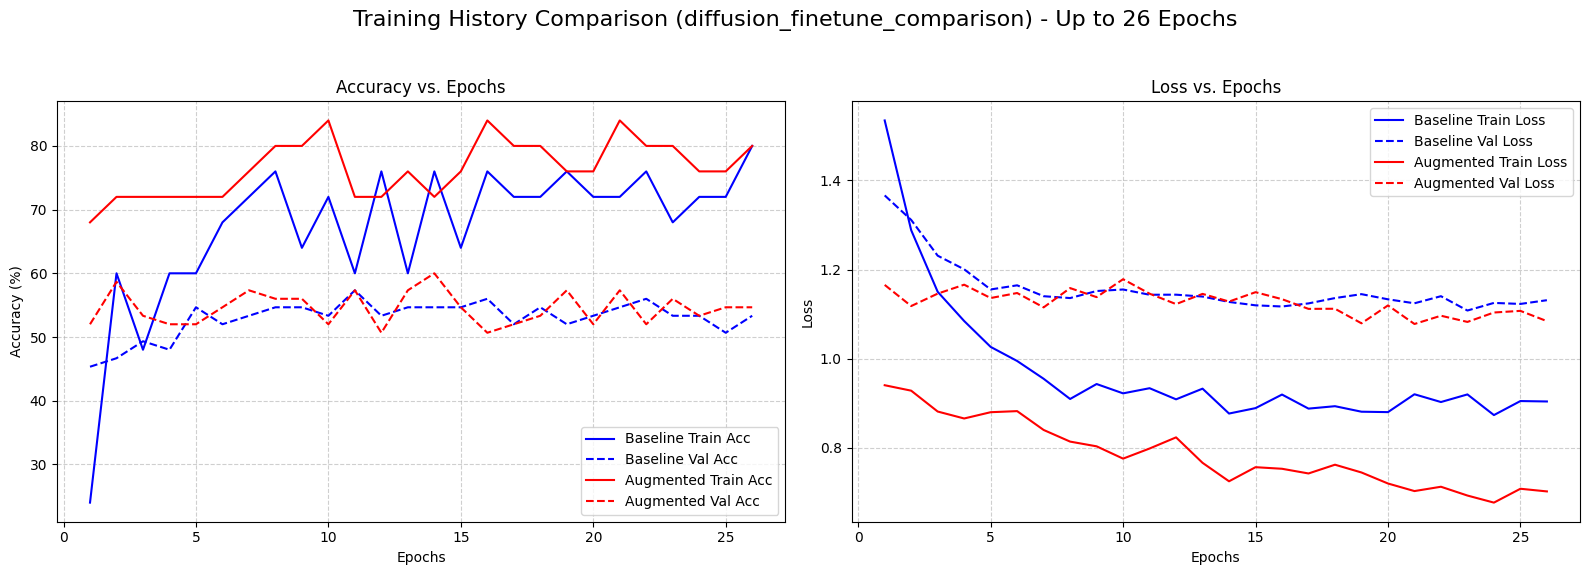

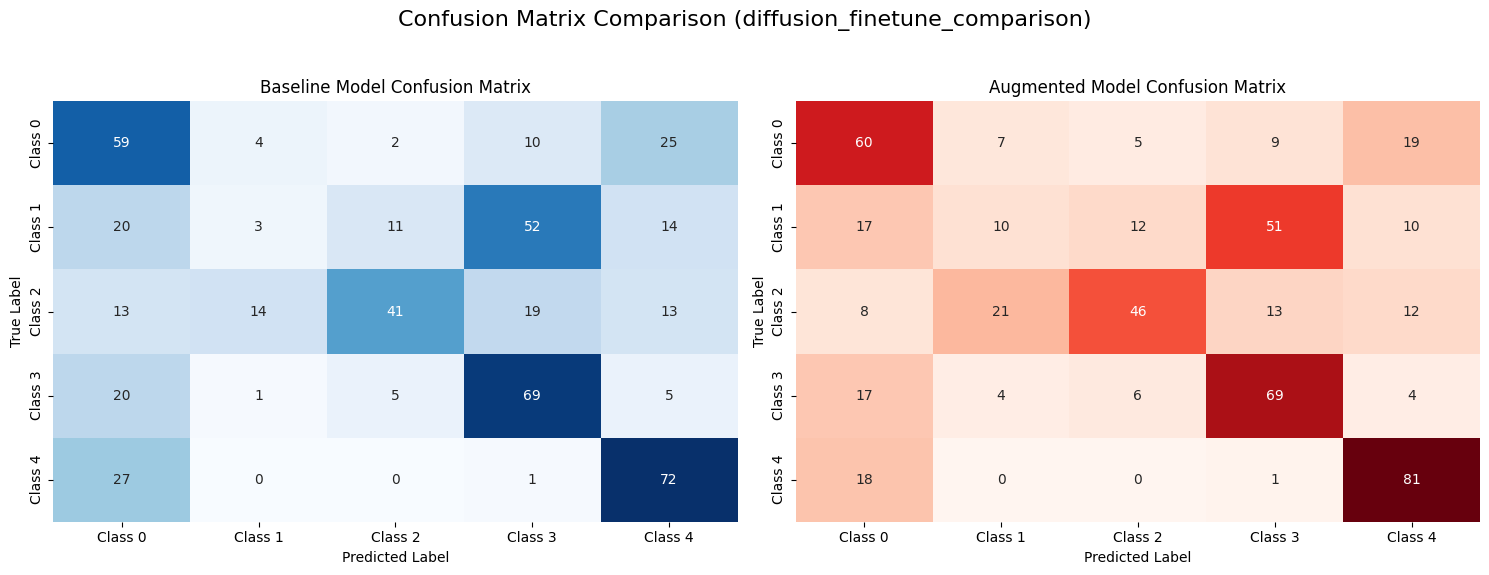


--- Test Accuracy Comparison (diffusion_finetune_comparison) ---
Baseline Model:  48.80%
Augmented Model: 53.20%
Absolute Improvement: +4.40%
Relative Improvement: +9.02%

--- Pipeline Finished ---

--------------------------------------------------------------------------------
Pipeline completed in 6.27 minutes.
  Final Baseline Test Acc: 48.80%
  Final Augmented Test Acc: 53.20%
--------------------------------------------------------------------------------


In [33]:
if __name__ == "__main__":
     print(f"Torch version: {torch.__version__}")
     print(f"CUDA available: {torch.cuda.is_available()}")
     if torch.cuda.is_available():
         print(f"CUDA version: {torch.version.cuda}")
         print(f"Device name: {torch.cuda.get_device_name(0)}")

     start_time = time.time()
     results_dict = None
     try:
         # Run the main pipeline function
         results_dict = run_diffusion_augmentation_pipeline()

     except Exception as e:
         # Catch any top-level exceptions not caught within the pipeline
         print("\n" + "#" * 60)
         print(" UNCAUGHT EXCEPTION IN MAIN EXECUTION ")
         print("#" * 60)
         print(f"Error Type: {type(e).__name__}")
         print(f"Error Details: {e}")
         traceback.print_exc() # Print detailed traceback

     finally:
         # This block always runs, even if errors occur
         end_time = time.time()
         duration_minutes = (end_time - start_time) / 60
         print("\n" + "-" * 80)
         if results_dict is not None:
             print(f"Pipeline completed in {duration_minutes:.2f} minutes.")
             if results_dict.get("baseline_metrics"):
                  baseline_acc = results_dict['baseline_metrics'].get('test_accuracy', 'N/A')
                  print(f"  Final Baseline Test Acc: {baseline_acc if isinstance(baseline_acc, str) else f'{baseline_acc:.2f}%'}")
             else:
                  print("  Baseline metrics not available.")

             if results_dict.get("augmented_metrics"):
                  augmented_acc = results_dict['augmented_metrics'].get('test_accuracy', 'N/A')
                  print(f"  Final Augmented Test Acc: {augmented_acc if isinstance(augmented_acc, str) else f'{augmented_acc:.2f}%'}")
             else:
                  print("  Augmented metrics not available.")
         else:
             print(f"Pipeline execution failed or was interrupted after {duration_minutes:.2f} minutes.")
         print("-" * 80)